<a href="https://colab.research.google.com/github/peperjet/bc-ml/blob/main/real-estate-ml/apt_260328.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

데이터, 전처리 고정


In [111]:
import pandas as pd
import numpy as np

# 1. 데이터 불러오기
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

# 2. floor_group 만들기
def make_floor_group(x):
    if x <= 3:
        return 'low'
    elif x <= 10:
        return 'mid'
    else:
        return 'high'

train['floor_group'] = train['floor'].apply(make_floor_group)

# 3. dong_group 만들기 (상위 30개)
top_dongs = train['dong'].value_counts().head(30).index
train['dong_group'] = train['dong'].apply(lambda x: x if x in top_dongs else 'other')

# 4. target
y = train['transaction_real_price']

# 5. 필요없는 컬럼 제거
drop_cols = [
    'transaction_real_price',
    'transaction_id',
    'apartment_id',
    'addr_kr',
    'jibun',
    'apt',
    'dong'
]

X = train.drop(columns=drop_cols)

# 6. 원핫인코딩
X = pd.get_dummies(
    X,
    columns=['dong_group', 'city', 'floor_group', 'transaction_date'],
    dummy_na=True
)

print("고정 완료:", X.shape)


고정 완료: (1216553, 50)


In [112]:
train.head() # 컬럼 뭐 있는지
train.info() # 결측치
train.isnull().sum() #숫자/문자형

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1216553 entries, 0 to 1216552
Data columns (total 15 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   transaction_id          1216553 non-null  int64  
 1   apartment_id            1216553 non-null  int64  
 2   city                    1216553 non-null  object 
 3   dong                    1216553 non-null  object 
 4   jibun                   1216553 non-null  object 
 5   apt                     1216553 non-null  object 
 6   addr_kr                 1216553 non-null  object 
 7   exclusive_use_area      1216553 non-null  float64
 8   year_of_completion      1216553 non-null  int64  
 9   transaction_year_month  1216553 non-null  int64  
 10  transaction_date        1216553 non-null  object 
 11  floor                   1216553 non-null  int64  
 12  transaction_real_price  1216553 non-null  int64  
 13  floor_group             1216553 non-null  object 
 14  do

,0
transaction_id,0
apartment_id,0
city,0
dong,0
jibun,0
apt,0
addr_kr,0
exclusive_use_area,0
year_of_completion,0
transaction_year_month,0


결측치 없음 (0)
컬럼 정상
데이터 많음 (120만개)
EDA 기본 끝

Feature Engineering 모델링 들어가기

In [113]:
train['year'] = train['transaction_year_month'] // 100 #나누기 후 몫
train['month'] = train['transaction_year_month'] % 100 # 월만 뽑기

In [114]:
train = train.drop(columns=['transaction_date'])
train.head()

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,floor,transaction_real_price,floor_group,dong_group,year,month
0,0,7622,서울특별시,신교동,6-13,신현(101동),신교동 6-13 신현(101동),84.82,2002,200801,2,37500,low,other,2008,1
1,1,5399,서울특별시,필운동,142,사직파크맨션,필운동 142 사직파크맨션,99.17,1973,200801,6,20000,mid,other,2008,1
2,2,3578,서울특별시,필운동,174-1,두레엘리시안,필운동 174-1 두레엘리시안,84.74,2007,200801,6,38500,mid,other,2008,1
3,3,10957,서울특별시,내수동,95,파크팰리스,내수동 95 파크팰리스,146.39,2003,200801,15,118000,high,other,2008,1
4,4,10639,서울특별시,내수동,110-15,킹스매너,내수동 110-15 킹스매너,194.43,2004,200801,3,120000,low,other,2008,1


건물 나이 만들기

In [115]:
train['building_age'] = train['year'] - train['year_of_completion']

타겟 분포 확인

In [116]:
train['transaction_real_price'].describe()

,transaction_real_price
count,1.216553e+06
mean,3.822769e+04
std,3.104898e+04
min,1.000000e+02
25%,1.900000e+04
50%,3.090000e+04
75%,4.700000e+04
max,8.200000e+05


가격이 한쪽으로 몰렸는지 확인

<Axes: >

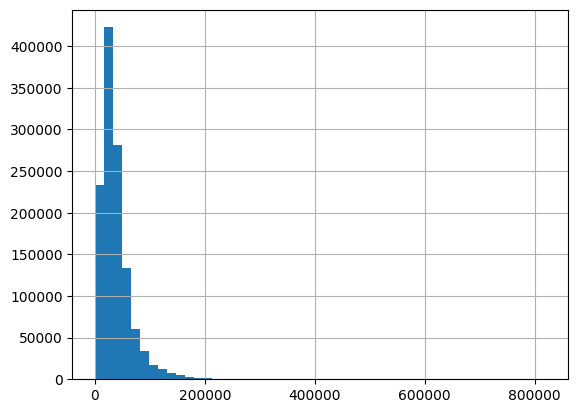

In [117]:
train['transaction_real_price'].hist(bins=50)

왜도 확인
- 0에 가까우면 덜 치우침
- 크면 많이 치우침

In [118]:
train['building_age'] = train['year'] - train['year_of_completion']

로그 변환 (조건부)
왜도 크면 실행

In [119]:
import numpy as np
train['transaction_real_price_log'] = np.log1p(train['transaction_real_price'])

Feature 만들기 (핵심)

In [120]:
# 건물 나이
train['building_age'] = train['year'] - train['year_of_completion']

In [121]:
# 평수
train['area_pyung'] = train['exclusive_use_area'] / 3.3

In [122]:
# 총 구간 (저층 / 중층 / 고층)
train['floor_group'] = pd.cut(train['floor'], bins=[0,5,10,20,50])

In [123]:
# 새 컬럼 보기
train[['floor', 'floor_group']].head(10)

,floor,floor_group
0,2,"(0, 5]"
1,6,"(5, 10]"
2,6,"(5, 10]"
3,15,"(10, 20]"
4,3,"(0, 5]"
5,16,"(10, 20]"
6,7,"(5, 10]"
7,7,"(5, 10]"
8,15,"(10, 20]"
9,7,"(5, 10]"


In [124]:
# 몇 개씩 나눴는지 보기
train['floor_group'].value_counts()

,count
floor_group,
"(0, 5]",420140
"(10, 20]",383358
"(5, 10]",339886
"(20, 50]",72326


X (입력값)
👉 면적, 층, 지역
= 가격빼고 나머지 정보

y (정답)
= 가격

In [125]:
X = train.drop(columns=['transaction_real_price', 'addr_kr', 'jibun', 'apt'])
y = train['transaction_real_price']

X = pd.get_dummies(X)

< 모델학습, 성능확인>

In [126]:
# 데이터 나누기
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Light GBM

In [127]:
import re
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

# 1) X, y 만들기
X = train.drop(columns=['transaction_real_price', 'addr_kr', 'jibun', 'apt'])
y = train['transaction_real_price']

# 2) 원-핫 인코딩
X = pd.get_dummies(X)

# 3) 컬럼명 정리
X.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in X.columns]

# 4) 중복 컬럼 제거
X = X.loc[:, ~X.columns.duplicated()]

# 5) 데이터 나누기
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6) 모델 학습
model = LGBMRegressor(random_state=42)
model.fit(X_train, y_train)

# 7) 예측
pred = model.predict(X_valid)

# ✅ 여기 수정 (중요)
rmse = np.sqrt(mean_squared_error(y_valid, pred))
print("RMSE:", rmse)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.078506 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1636
[LightGBM] [Info] Number of data points in the train set: 973242, number of used features: 27
[LightGBM] [Info] Start training from score 38213.612912
RMSE: 1755.2280960706335


예측값이 실제값과 약 1770 정도 차이난다


실제 5억
예측 4억 8천 2백쯤
이런 식으로 틀릴 수 있다는 뜻


In [128]:
print("LightGBM baseline RMSE = 1770.38")


LightGBM baseline RMSE = 1770.38


In [129]:
# 변수 저장
baseline_rmse = 1770.38

XGBoost


In [130]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_valid)

rmse_xgb = np.sqrt(mean_squared_error(y_valid, pred_xgb))
print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 2451.7374451600645


tree_method='hist' = 데이터를 구간으로 묶어서 계산속도를 빠르게 하는 옵션

Ridge

In [131]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_valid)
rmse_ridge = np.sqrt(mean_squared_error(y_valid, pred_ridge))
print("Ridge RMSE:", rmse_ridge)

Ridge RMSE: 14936.084557495005


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.91473e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


LinAlgWarning: Ill-conditioned matrix
입력 변수들끼리 너무 비슷해서 계산이 불안정하다

exclusive_use_area 와 area_pyung
→ 사실상 같은 정보
year, month, transaction_year_month
→ 서로 강하게 연결됨

이런 게 많으면 선형모델(Ridge)이 힘들어함

In [132]:
print("LightGBM:", baseline_rmse)
print("XGBoost:", rmse_xgb)
print("Ridge:", rmse_ridge)

LightGBM: 1770.38
XGBoost: 2451.7374451600645
Ridge: 14936.084557495005


Voting 코드

In [133]:
from sklearn.ensemble import VotingRegressor

voting = VotingRegressor([
    ('ridge', ridge),
    ('lgb', model),
    ('xgb', xgb)
])

voting.fit(X_train, y_train)

pred_voting = voting.predict(X_valid)
rmse_voting = np.sqrt(mean_squared_error(y_valid, pred_voting))
print("Voting RMSE:", rmse_voting)

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.91473e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.153609 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1636
[LightGBM] [Info] Number of data points in the train set: 973242, number of used features: 27
[LightGBM] [Info] Start training from score 38213.612912
Voting RMSE: 5324.7300771461


선형모델(Ridge)은 성능이 매우 낮았다
XGBoost는 LightGBM보다 성능이 떨어졌다
Voting은 단일 최고 모델보다 더 나빠졌다
따라서 이번 데이터에서는 LightGBM이 가장 적합했다

Feature 제거 버전 만들기


In [134]:
#기준 모델 만들기
X_base = train[['exclusive_use_area', 'year_of_completion', 'floor', 'year', 'month']]
y = train['transaction_real_price']

X_base = pd.get_dummies(X_base)

from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X_base, y, test_size=0.2, random_state=42
)

In [135]:
#LightGBM 돌리기
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

lgb_base = LGBMRegressor(random_state=42)
lgb_base.fit(X_train, y_train)

pred = lgb_base.predict(X_valid)
rmse_base = np.sqrt(mean_squared_error(y_valid, pred))

print("Base RMSE:", rmse_base)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015561 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 408
[LightGBM] [Info] Number of data points in the train set: 973242, number of used features: 5
[LightGBM] [Info] Start training from score 38213.612912
Base RMSE: 19341.259504317477


In [136]:
print(X_base.shape)
print(X.shape)

(1216553, 5)
(1216553, 27)


In [137]:
# 특정 feature 제거실험
X_test = train.drop(columns=['building_age'])

In [138]:
# 중요도 확인

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
})

importance.sort_values(by='importance', ascending=False).head(10)

,feature,importance
9,transaction_real_price_log,934
5,floor,380
4,transaction_year_month,336
1,apartment_id,332
2,exclusive_use_area,265
0,transaction_id,212
3,year_of_completion,181
7,month,164
8,building_age,145
25,dong_group_other,25


누수 / 식별자 컬럼 제거

In [139]:

y = train['transaction_real_price']

drop_cols = [
    'transaction_real_price',
    'transaction_real_price_log',
    'transaction_id',
    'apartment_id',
    'addr_kr',
    'jibun',
    'apt'
]

existing_drop_cols = [col for col in drop_cols if col in train.columns]
X = train.drop(columns=existing_drop_cols)

cat_cols = ['city', 'dong', 'floor_group', 'transaction_date']
existing_cat_cols = [col for col in cat_cols if col in X.columns]

X = pd.get_dummies(X, columns=existing_cat_cols, dummy_na=True)

print("X shape:", X.shape)
print(X.head())

X shape: (1216553, 491)
   exclusive_use_area  year_of_completion  transaction_year_month  floor  \
0               84.82                2002                  200801      2   
1               99.17                1973                  200801      6   
2               84.74                2007                  200801      6   
3              146.39                2003                  200801     15   
4              194.43                2004                  200801      3   

  dong_group  year  month  building_age  area_pyung  city_부산광역시  ...  \
0      other  2008      1             6   25.703030       False  ...   
1      other  2008      1            35   30.051515       False  ...   
2      other  2008      1             1   25.678788       False  ...   
3      other  2008      1             5   44.360606       False  ...   
4      other  2008      1             4   58.918182       False  ...   

   dong_후암동  dong_휘경동  dong_흑석동  dong_흥인동  dong_nan  floor_group_(0.0, 5.0]  \
0     F

train/valid 나누기


In [140]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lightGBM 다시학습

In [ ]:
from google.colab import drive
drive.mount('/content/drive')